In [1]:
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import torch
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

%config Completer.use_jedi = False

In [3]:
if torch.cuda.is_available():
    device = torch.device(type = "cuda", index = 0)
else:
    device = torch.device(type = "cpu", index = 0)

print(device)

cuda:0


In [4]:
# FFtrainDS = datasets.FashionMNIST(
#     root = "data",
#     train = True,
#     download = True,
#     transform = ToTensor(),
# )

FFtestDS = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
)

trainDS = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
)
testDS = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
)

In [5]:
print(trainDS, end = "\n\n")
print(testDS)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [6]:
batchSize = 128

trainDL = DataLoader(
    dataset = trainDS,
    batch_size = batchSize,
    shuffle = True,
    num_workers=16,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True
)
testDL = DataLoader(
    dataset = testDS,
    batch_size = batchSize, 
    shuffle = True,
    num_workers=8,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True
)

FullDtestDL = DataLoader(
    dataset = testDS,
    batch_size = len(testDS), 
    shuffle = True,
    num_workers=8,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True
)

FullFtestDL = DataLoader(
    dataset = FFtestDS,
    batch_size = len(FFtestDS), 
    shuffle = True,
    num_workers=8,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True
)

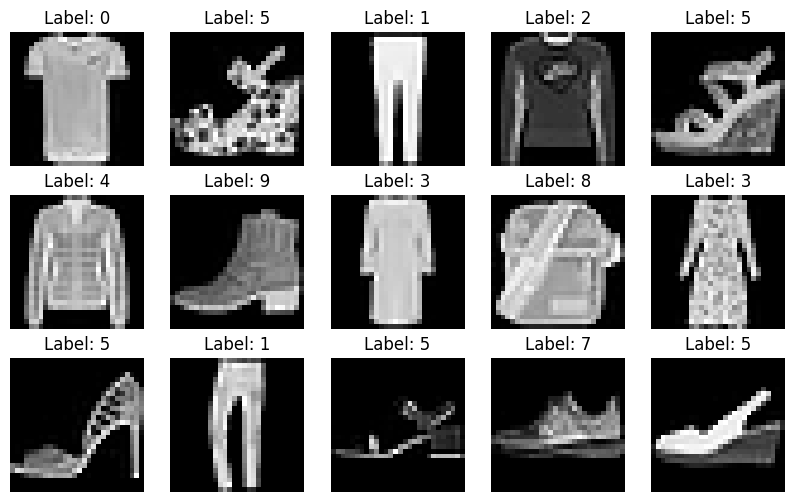

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Random
random_indices = (np.random.rand(15) * len(FFtestDS)).astype(int)
random_images = [FFtestDS[i][0] for i in random_indices]
random_labels = [FFtestDS[i][1] for i in random_indices]

# Plot
plt.figure(figsize=(10,6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(random_images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {random_labels[i]}")
    plt.axis('off')
plt.show()

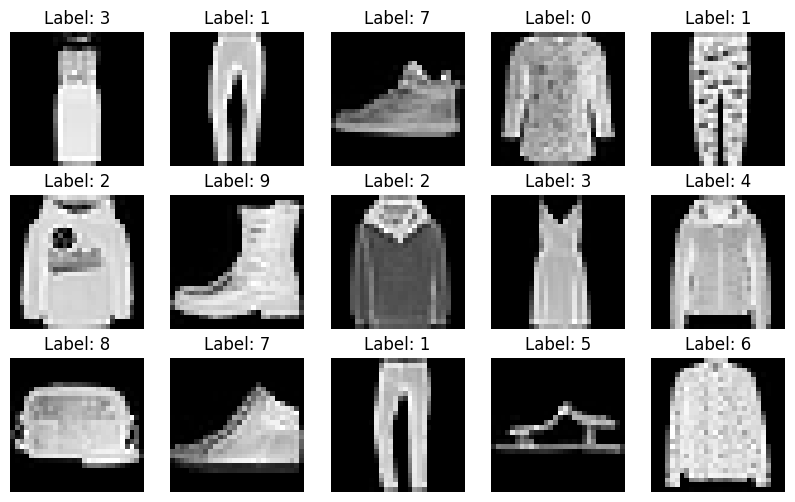

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Random
random_indices = (np.random.rand(15) * len(FFtestDS)).astype(int)
random_images = [FFtestDS[i][0] for i in random_indices]
random_labels = [FFtestDS[i][1] for i in random_indices]

# Plot
plt.figure(figsize=(10,6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(random_images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {random_labels[i]}")
    plt.axis('off')
plt.show()

In [9]:
class DR_CNN_Dynamic(nn.Module):
    def __init__(self, convConfig=(1,8,16,32,64), bnAt = (True,True,True,True), mpAt = (True,True,True,True), convKSP = ((3,3),1,0), poolMSP = ((2,2),2,0), lin = ("default","res"), showDim=False, initSize = (28,1), nClasses = 10):
        super().__init__()
        
        # HyperParameters
        self.convCount = len(convConfig) - 1
        self.layers = nn.ModuleList()
        self.res = initSize
        
        
        # MaxPool and ReLU
        self.mp=nn.MaxPool2d(kernel_size=poolMSP[0],stride=poolMSP[1],padding=poolMSP[2])
        self.relu = nn.ReLU()
        
        # Convulation Network
        if showDim: print ("Init :", self.res)
        for i in range(self.convCount):
            if True:
                self.layers.append(nn.Conv2d(in_channels = convConfig[i], out_channels = convConfig[i+1], kernel_size = convKSP[0], stride = convKSP[1], padding = convKSP[2]))
                self.res = (int((self.res[0] - convKSP[0][0] + 2 * convKSP[2]) / convKSP[1] + 1), convConfig[i+1])
                if showDim: print ("Cv", i, ":",self.res)
                    
            if bnAt[i]:
                self.layers.append(nn.BatchNorm2d(self.res[1]))
                if showDim: print ("BN", i, ":", self.res)   
                    
            if True:
                self.layers.append(self.relu)
                
            if mpAt[i]:
                self.layers.append(self.mp)
                self.res = (int((self.res[0] - poolMSP[0][0] + 2 * poolMSP[2]) / poolMSP[1] + 1), self.res[1])
                if showDim: print ("MP", i, ":", self.res)

        # Fully Connected Network
        self.layers.append(nn.Flatten())
        self.res = self.res[0]**2 * self.res[1]
        if showDim: print("Fltn :", self.res)

        self.prevres = self.res 
        for i in lin:
            if i == "res":
                self.layers.append(nn.Linear(in_features=self.res, out_features=nClasses))
                self.res = nClasses
                if showDim: print("FCNW :", self.res)
                if showDim: print("Result Size:", self.res)
                break
            else:
                self.layers.append(nn.Linear(in_features=self.res, out_features=i))
                self.prevres = self.res
                self.res = i
                self.layers.append(nn.BatchNorm1d(num_features=self.res))
                self.layers.append(nn.ReLU())
                if showDim: print("FCNW :", self.res)
        
    def forward(self,x):
        i = 1
        for layer in self.layers:
            x = layer(x)
        return x

In [10]:
class FM_ANN_Dynamic(nn.Module):
    def __init__(self, lin = (400,200,"res"), showDim=False, initSize = 784, nClasses = 10, activ = "ReLU", bn = True):
        super().__init__()
        
        # HyperParameters
        self.layers = nn.ModuleList()
        self.res = initSize
        if showDim: print ("Ini:", self.res)
        
        # Activation
        if activ == "Sig":
            self.activ = nn.Sigmoid()
        elif activ == "none":
            self.activ = None
        else:
            self.activ = nn.ReLU()
        
        for i in lin:
            if i == "res":
                if showDim: print("FC + BN        :" if bn else "FC             :", self.res, "->", i)
                self.layers.append(nn.Linear(in_features=self.res, out_features=nClasses))
                self.res = nClasses
                if bn:
                    self.layers.append(nn.BatchNorm1d(num_features=nClasses))
                if showDim: print("Result Size:", self.res)
                break
            else:
                if showDim: print("FC + BN + Acti :", self.res, "->", i)
                self.layers.append(nn.Linear(in_features=self.res, out_features=i))
                self.res = i
                if bn:
                    self.layers.append(nn.BatchNorm1d(num_features=self.res))
                if activ != "none":
                    self.layers.append(self.activ)
        
    def forward(self,x):
        i = 1
        for layer in self.layers:
            x = layer(x)
        return x

In [11]:
logmodel = FM_ANN_Dynamic(
    lin=("res",),
    showDim=True,
    initSize=784,
    nClasses=10,
    activ="none",
    bn=False
)


print("\n", "-"*50, sep="")
print(logmodel)

Ini: 784
FC             : 784 -> res
Result Size: 10

--------------------------------------------------
FM_ANN_Dynamic(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=10, bias=True)
  )
)


In [12]:
model = FM_ANN_Dynamic(lin = (30,20,"res"), 
                        showDim = True)

print("\n", "-"*50, sep="")
print(model)

Ini: 784
FC + BN + Acti : 784 -> 30
FC + BN + Acti : 30 -> 20
FC + BN        : 20 -> res
Result Size: 10

--------------------------------------------------
FM_ANN_Dynamic(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=30, bias=True)
    (1): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=30, out_features=20, bias=True)
    (4): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=20, out_features=10, bias=True)
    (7): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (activ): ReLU()
)


In [13]:
def epochTrainer(trainDL, model, loss_fn, optimizer, ver = True, CNN = False, PT = False):
    # Set model in Train mode
    # if not PT:
    #     model.train()
    totalLoss = 0
    totalCorrect = 0

    # print(next(model.parameters()).device)
    model = model.to(device)
    is_cnn = not isinstance(next(model.parameters()), torch.nn.parameter.Parameter) or len(next(model.parameters()).shape) > 2
    
    for batchNo, (images, labels) in enumerate(trainDL):
        # print(device)
        
        # Convert to device
        if not is_cnn and images.ndim > 2:
            images = torch.reshape(images, shape=[-1, 784]).to(device)
        else:
            images = images.to(device)

        labels = labels.to(device)
        
        # Forward pass the batch
        fwdPass = model(images)
        # print(images.device, labels.device, next(model.parameters()).device)
        # print(next(model.parameters()).device)

        # Batch & Total - Loss & Correct Count
        currLoss = loss_fn(fwdPass,labels)
        totalLoss += currLoss.item()
        currCorrect = (torch.argmax(fwdPass,dim=1) == labels).type(torch.float).sum()
        totalCorrect += currCorrect.item()
        
        # Average Loss (per batch) and Average Accuracy (fractional, per item)
        avgLoss = round(totalLoss / (batchNo + (images.shape[0] / batchSize)), 4)
        avgAccuracy = round((totalCorrect / (( batchNo * batchSize + images.shape[0]))) * 100, 4)
        # print(loss_fn.requires_grad, loss_fn.grad_fn)

        # Backpropogate
        optimizer.zero_grad()
        currLoss.backward()
        optimizer.step()
        
        # print("Current device for model:", next(model.parameters()).device)
        # print("Current device for images:", labels.device)
                    
        # Display for every multiple of 200
        if batchNo%200 == 0 and ver:
            print("Train Batch:", batchNo+1, "/",len(trainDL), "Running Loss:",avgLoss, "Running Accuracy:",avgAccuracy)
    
    # Post-current epoch Loss & Accuracy
    endEpochLoss = avgLoss
    endEpochAccu = avgAccuracy
    return endEpochLoss, endEpochAccu

In [14]:
def epochValidate(validDL, model, loss_fn, ver = True, metric = False, show_mis=False, max_mis=25, CNN = False):
    # Test       Mode
    model.eval()
    totalLoss = 0
    totalCorrect = 0

    all_preds = []
    all_labels = []
    all_images = []
    
    is_cnn = not isinstance(next(model.parameters()), torch.nn.parameter.Parameter) or len(next(model.parameters()).shape) > 2

    # print(next(model.parameters()).device)
    
    with torch.no_grad():
        for batchNo, (val_images, val_labels) in enumerate(validDL):            
            # Convert to device
            
            if not is_cnn and val_images.ndim > 2:
                val_images = torch.reshape(val_images, shape=[-1, 784]).to(device)
            else:
                val_images = val_images.to(device)

            val_labels = val_labels.to(device)
            
            # Forward pass the batch
            val_fwdPass = model(val_images)

            # print(val_images.device, val_labels.device, next(model.parameters()).device)
            # print(next(model.parameters()).device)

                
            # Loss & Correct Count
            val_currLoss = loss_fn(val_fwdPass, val_labels)
            totalLoss += val_currLoss.item()
            totalCorrect += (torch.argmax(val_fwdPass, dim=1) == val_labels).type(torch.float).sum().item()

            all_preds.extend(torch.argmax(val_fwdPass, dim=1).cpu().numpy())
            all_labels.extend(val_labels.cpu().numpy())
            all_images.extend(val_images.cpu())

            # print("Current device for model:", next(model.parameters()).device)
            # print("Current device for images:", val_images.device)
            
            # Display for every multiple of 25
            if batchNo%25==0 and ver:
                running_loss=round(totalLoss / (batchNo + (val_images.shape[0] / batchSize)), 4)
                running_acc=round((totalCorrect / (( batchNo * batchSize + val_images.shape[0]))) * 100, 4)
                print("Valid Batch:", batchNo+1, "/",len(validDL), "Running Loss:",running_loss, "Running Accuracy:",running_acc)            
            
    # Post-current epoch Loss & Accuracy
    val_avgLoss = round(totalLoss / len(validDL), 4)
    val_avgAccu = round((totalCorrect / len(validDL.dataset)), 6)

    if metric:
        # Convert to NumPy
        y_true = np.array(val_labels.cpu())
        y_pred = np.array(torch.argmax(val_fwdPass, dim=1).cpu())
    
        # Compute Metrics
        accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
        precision = round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
        recall = round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
        f1 = round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
        cm = confusion_matrix(y_true, y_pred)

        print("Test      :")
        print(f"Precision     : {precision}%")
        print(f"Recall        : {recall}%")
        print(f"F1-Score      : {f1}%")

        class_names = [str(i) for i in range(cm.shape[0])]
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='crest', 
                    xticklabels=class_names, yticklabels=class_names,
                    cbar_kws={'label': 'Count'}, annot_kws={"size": 12})
        plt.title(f"Confusion Matrix (Accuracy: {accuracy}%)", fontsize=14, weight='bold')
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        if show_mis:
            num_misclassified = max_mis
            mis_idx = np.where(y_true != y_pred)[0]
            if len(mis_idx) > 0:
                plt.figure(figsize=(12,10))
                for i, idx in enumerate(mis_idx[:num_misclassified]):
                    plt.subplot(5, 5, i + 1)
                    plt.imshow(all_images[idx].view(28,28), cmap='gray')
                    plt.title(f"P:{y_pred[idx]} / T:{y_true[idx]}", fontsize=10, color='red')
                    plt.axis('off')
                plt.suptitle("Sample Misclassifications", fontsize=14, weight='bold')
                plt.tight_layout()
                plt.show()
            else:
                print("No misclassifications found!")



        
        return val_avgLoss, val_avgAccu, precision, recall, f1, cm
        
    return val_avgLoss, val_avgAccu

In [15]:
# def epochValidate(validDL, model, loss_fn, ver=True, metric=False, show_misclassified=True, num_misclassified=12):
#     model.eval()
#     totalLoss = 0
#     totalCorrect = 0
#     all_preds = []
#     all_labels = []
#     all_images = []

#     with torch.no_grad():
#         for batchNo, (val_images, val_labels) in enumerate(validDL):
#             # Move to device
#             val_images = val_images.to(device)
#             val_labels = val_labels.to(device)
            
#             # Flatten for linear model
#             val_images_flat = val_images.view(val_images.size(0), -1)

#             # Forward pass
#             val_outputs = model(val_images_flat)
#             val_loss = loss_fn(val_outputs, val_labels)
            
#             # Update totals
#             totalLoss += val_loss.item()
#             totalCorrect += (torch.argmax(val_outputs, dim=1) == val_labels).sum().item()

#             # Store predictions and true labels for metrics
#             all_preds.extend(torch.argmax(val_outputs, dim=1).cpu().numpy())
#             all_labels.extend(val_labels.cpu().numpy())
#             all_images.extend(val_images.cpu())

#             if batchNo % 25 == 0 and ver:
#                 running_loss = round(totalLoss / (batchNo + 1), 2)
#                 running_acc = round((totalCorrect / ((batchNo + 1) * validDL.batch_size)) * 100, 2)
#                 print(f"Valid Batch: {batchNo+1}/{len(validDL)} | Loss: {running_loss} | Acc: {running_acc}%")

#     # Average loss and accuracy
#     val_avgLoss = round(totalLoss / len(validDL), 4)
#     val_avgAccu = round((totalCorrect / len(validDL.dataset)), 6)

#     if metric:
#         y_true = np.array(all_labels)
#         y_pred = np.array(all_preds)
        
#         # Metrics
#         accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
#         precision = round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
#         recall = round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
#         f1 = round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
#         cm = confusion_matrix(y_true, y_pred)

#         print("\nTest       Metrics:")
#         print(f"Accuracy  : {accuracy}%")
#         print(f"Precision : {precision}%")
#         print(f"Recall    : {recall}%")
#         print(f"F1-Score  : {f1}%")

#         # Confusion matrix
#         plt.figure(figsize=(8,6))
#         sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
#                     xticklabels=[str(i) for i in range(10)],
#                     yticklabels=[str(i) for i in range(10)])
#         plt.title(f"Confusion Matrix (Acc: {accuracy}%)", fontsize=13, weight='bold')
#         plt.xlabel("Predicted")
#         plt.ylabel("True")
#         plt.show()

#         # Misclassifications
#         if show_misclassified:
#             mis_idx = np.where(y_true != y_pred)[0]
#             if len(mis_idx) > 0:
#                 plt.figure(figsize=(12, 6))
#                 for i, idx in enumerate(mis_idx[:num_misclassified]):
#                     plt.subplot(3, 4, i + 1)
#                     plt.imshow(all_images[idx].squeeze(), cmap='gray')
#                     plt.title(f"P:{y_pred[idx]} / T:{y_true[idx]}", fontsize=10, color='red')
#                     plt.axis('off')
#                 plt.suptitle("Sample Misclassifications", fontsize=14, weight='bold')
#                 plt.tight_layout()
#                 plt.show()
#             else:
#                 print("No misclassifications found!")

#         return val_avgLoss, val_avgAccu, precision, recall, f1, cm

#     return val_avgLoss, val_avgAccu


# ANN

## Train ANN

In [16]:
model = FM_ANN_Dynamic(lin = (30,20,"res"), 
                        showDim = True)

model=model.to(device)
loss_fn=nn.CrossEntropyLoss().to(device)
lr=0.001
sgdoptimizer=torch.optim.SGD(params=model.parameters(), lr=lr)
optimizer=torch.optim.Adam(params=model.parameters(), lr=lr)
n_epochs=50

for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=epochTrainer(trainDL,model,loss_fn,optimizer, ver=False)
    print("Training  :", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    val_epoch_loss, val_epoch_acc=epochValidate(testDL,model,loss_fn, ver = False)
    print("Test      :", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc*100)
    print("--------------------------------------------------")

Ini: 784
FC + BN + Acti : 784 -> 30
FC + BN + Acti : 30 -> 20
FC + BN        : 20 -> res
Result Size: 10
Epoch No: 1
Training  : Epoch Loss: 0.5672 Epoch Accuracy: 89.1133
Test      : Epoch Loss: 0.3069 Epoch Accuracy: 94.39
--------------------------------------------------
Epoch No: 2
Training  : Epoch Loss: 0.1732 Epoch Accuracy: 94.8667
Test      : Epoch Loss: 0.1311 Epoch Accuracy: 96.1
--------------------------------------------------
Epoch No: 3
Training  : Epoch Loss: 0.1224 Epoch Accuracy: 96.2983
Test      : Epoch Loss: 0.1396 Epoch Accuracy: 95.87
--------------------------------------------------
Epoch No: 4
Training  : Epoch Loss: 0.1037 Epoch Accuracy: 96.82
Test      : Epoch Loss: 0.1301 Epoch Accuracy: 96.21
--------------------------------------------------
Epoch No: 5
Training  : Epoch Loss: 0.0903 Epoch Accuracy: 97.2233
Test      : Epoch Loss: 0.1321 Epoch Accuracy: 96.22
--------------------------------------------------
Epoch No: 6
Training  : Epoch Loss: 0.084 E

### Results - ANN

#### ANN on MNIST

Test      :
Precision     : 96.53%
Recall        : 96.52%
F1-Score      : 96.52%


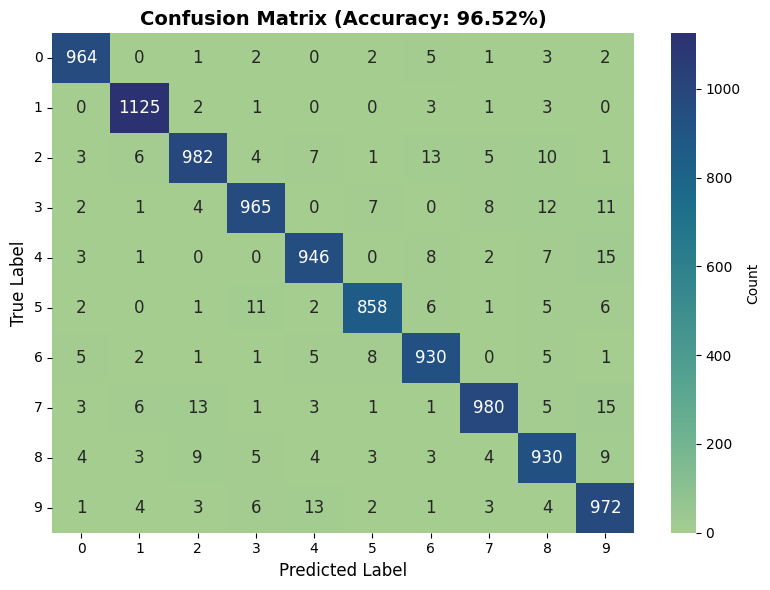

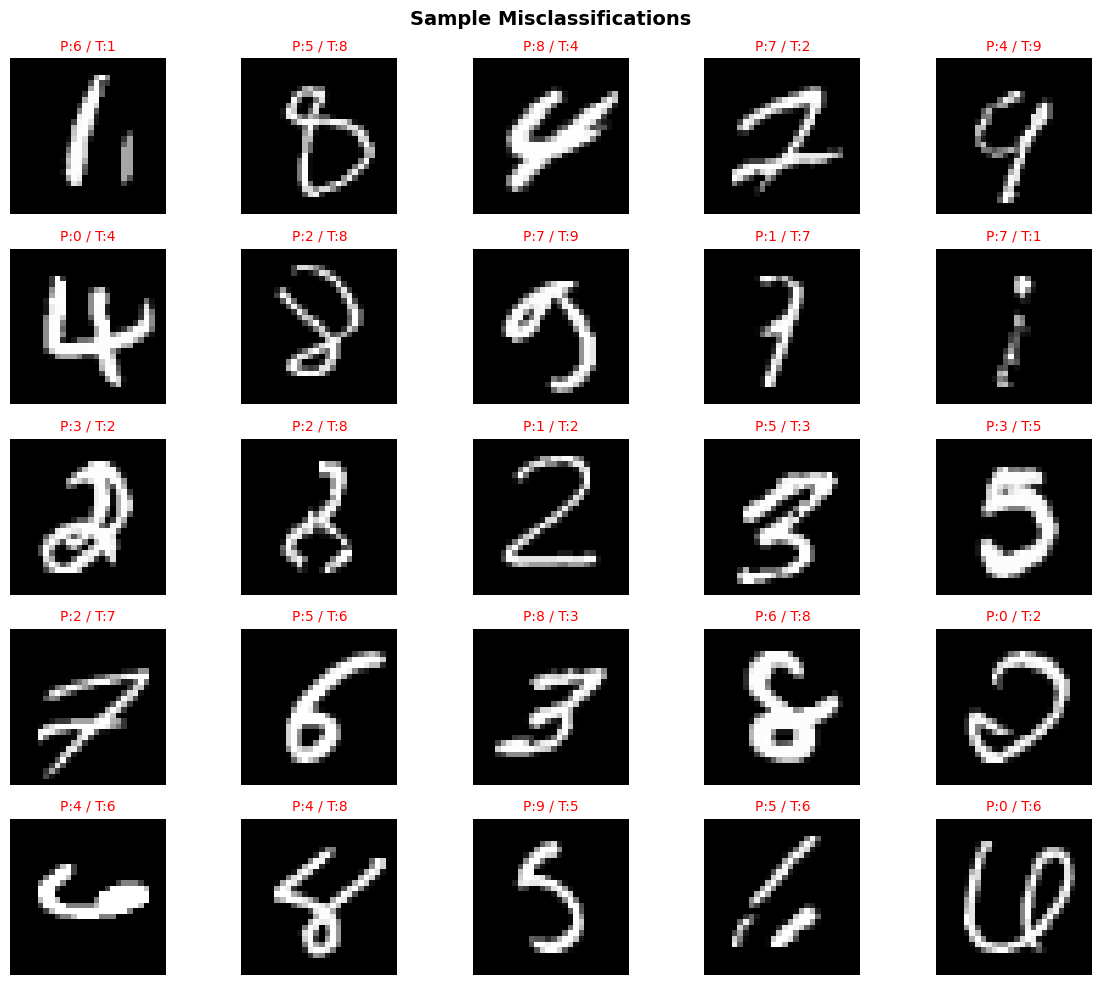

In [17]:
_ = epochValidate(FullDtestDL,model,loss_fn, ver = False, metric = True, show_mis = True)

#### ANN on FasionMNIST

Test      :
Precision     : 8.77%
Recall        : 3.94%
F1-Score      : 3.22%


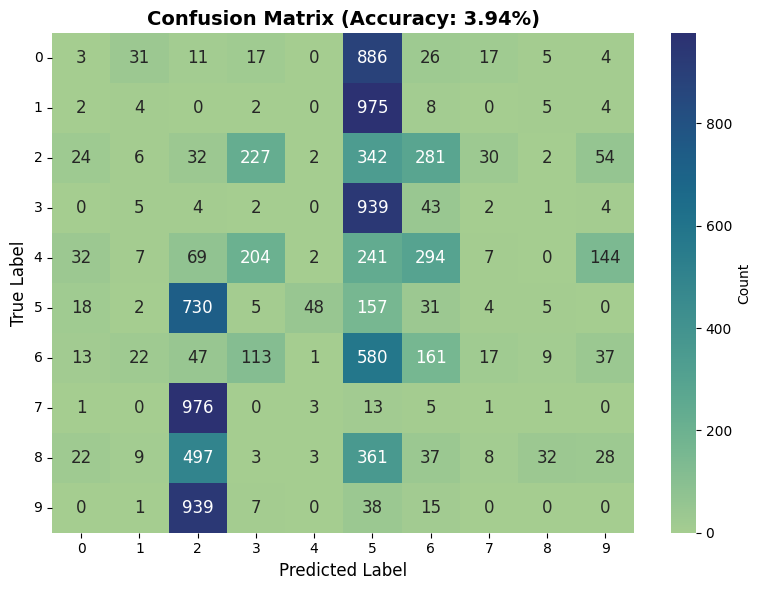

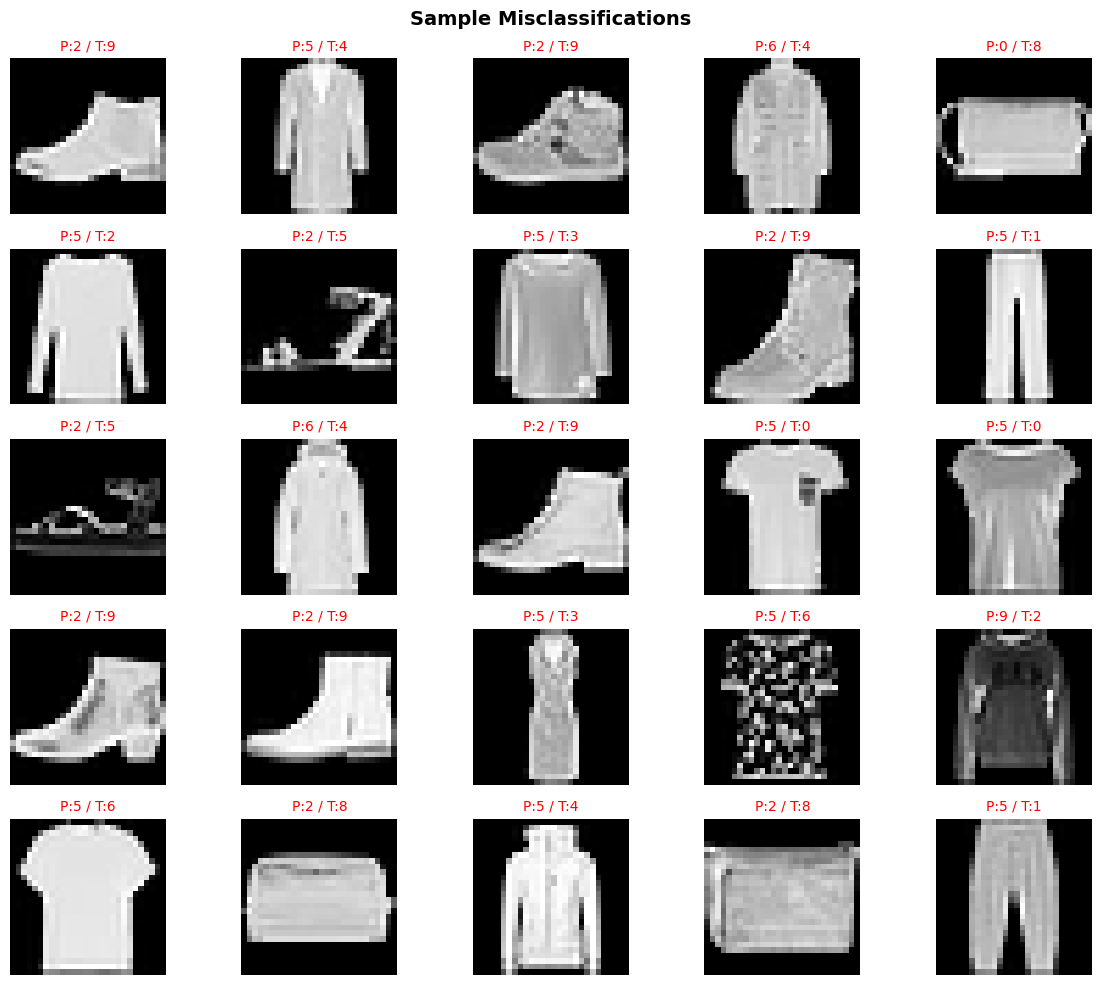

In [18]:
_ = epochValidate(FullFtestDL,model,loss_fn, ver = False, metric = True, show_mis = True)

## Train Logistic Regression

In [19]:
lrmodel = FM_ANN_Dynamic(
    lin=("res",),
    showDim=False,
    initSize=784,
    nClasses=10,
    activ="none",
    bn=False
)

lrmodel=lrmodel.to(device)
loss_fn=nn.CrossEntropyLoss()
lr=0.001
sgdoptimizer=torch.optim.SGD(params=lrmodel.parameters(), lr=lr)
optimizer=torch.optim.Adam(params=lrmodel.parameters(), lr=lr)
n_epochs=50

print(lrmodel)

for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=epochTrainer(trainDL,lrmodel,loss_fn,optimizer, ver=False)
    print("Training  :", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    val_epoch_loss, val_epoch_acc=epochValidate(testDL,lrmodel,loss_fn, ver = False)
    print("Test      :", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc*100)
    print("--------------------------------------------------")

FM_ANN_Dynamic(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=10, bias=True)
  )
)
Epoch No: 1
Training  : Epoch Loss: 0.6654 Epoch Accuracy: 84.7783
Test      : Epoch Loss: 0.3821 Epoch Accuracy: 90.14999999999999
--------------------------------------------------
Epoch No: 2
Training  : Epoch Loss: 0.3606 Epoch Accuracy: 90.3567
Test      : Epoch Loss: 0.3218 Epoch Accuracy: 91.36
--------------------------------------------------
Epoch No: 3
Training  : Epoch Loss: 0.3187 Epoch Accuracy: 91.225
Test      : Epoch Loss: 0.2953 Epoch Accuracy: 91.8
--------------------------------------------------
Epoch No: 4
Training  : Epoch Loss: 0.2993 Epoch Accuracy: 91.6833
Test      : Epoch Loss: 0.2841 Epoch Accuracy: 92.2
--------------------------------------------------
Epoch No: 5
Training  : Epoch Loss: 0.2874 Epoch Accuracy: 92.0267
Test      : Epoch Loss: 0.277 Epoch Accuracy: 92.16
--------------------------------------------------
Epoch No: 6
Training  : Epoch 

### Results - Logistic

Test      :
Precision     : 92.62%
Recall        : 92.59%
F1-Score      : 92.58%


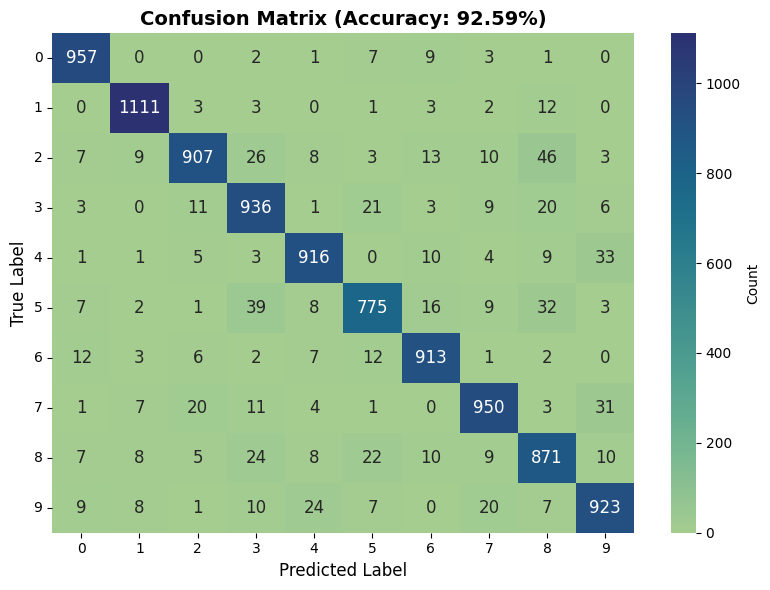

In [20]:
_ = epochValidate(FullDtestDL,lrmodel,loss_fn, ver = False, metric = True)

## Train - Random Forest

In [21]:
X_train = trainDS.data.reshape(-1, 28*28).numpy()
y_train = trainDS.targets.numpy()
X_test  = testDS.data.reshape(-1, 28*28).numpy()
y_test  = testDS.targets.numpy()

X_train = X_train / 255.0
X_test  = X_test / 255.0

rf = RandomForestClassifier(
    n_estimators=100,      
    max_depth=20,          
    n_jobs=-1,
    random_state=42
)
print("Training Random Forest...")
rf.fit(X_train, y_train)

Training Random Forest...


RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)

In [22]:
def testRF(y_test,y_pred):
    accuracy  = round(accuracy_score(y_test, y_pred) * 100, 2)
    precision = round(precision_score(y_test, y_pred, average='weighted') * 100, 2)
    recall    = round(recall_score(y_test, y_pred, average='weighted') * 100, 2)
    f1        = round(f1_score(y_test, y_pred, average='weighted') * 100, 2)
    
    print(f"\nRandom Forest:")
    print(f"Accuracy : {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall   : {recall}%")
    print(f"F1-score : {f1}%")
    
    cm = confusion_matrix(y_test, y_pred)
    class_names = [str(i) for i in range(cm.shape[0])]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', 
                        xticklabels=class_names, yticklabels=class_names,
                        cbar_kws={'label': 'Count'}, annot_kws={"size": 12})
    plt.title(f"Confusion Matrix (Accuracy: {accuracy}%)", fontsize=14, weight='bold')
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


    mis_idx = np.where(y_pred != y_test)[0]
    
    print(f"\nTotal misclassifications: {len(mis_idx)} / {len(y_test)}")
    
    num_show = min(25, len(mis_idx))
    samples = mis_idx[:num_show]
    
    # Create a 5x5 grid
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    fig.suptitle("Random Forest Misclassified MNIST Digits", fontsize=16)
    
    for i, ax in enumerate(axes.flat[:num_show]):
        idx = samples[i]
        ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y_test[idx]}", fontsize=10, color="red")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()


### Result - Random Forest


Random Forest:
Accuracy : 96.8%
Precision: 96.8%
Recall   : 96.8%
F1-score : 96.8%


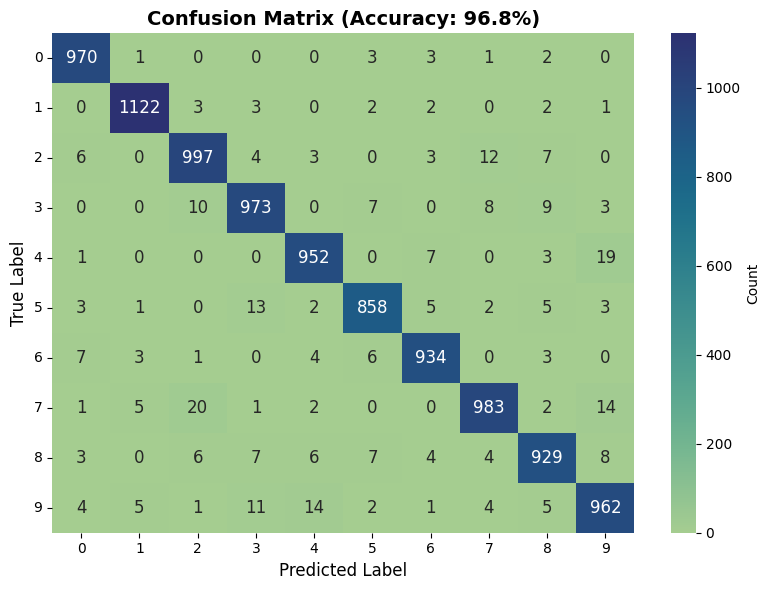


Total misclassifications: 320 / 10000


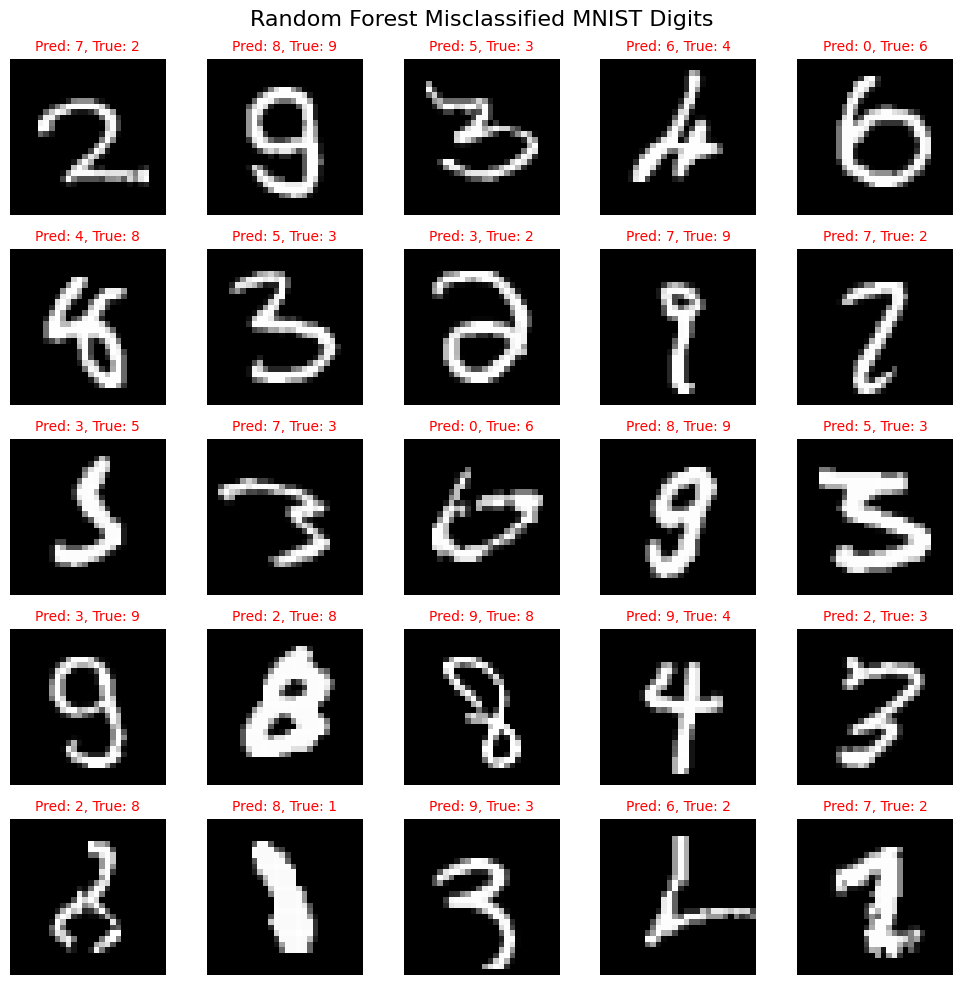

In [23]:
y_pred = rf.predict(X_test)

testRF(y_test,y_pred)

## t-SNE

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ---------- CONFIG ----------
layer_no = 3     # <-- change this to your 20-neuron layer index
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ----------------------------


def extract_features(model, dataloader, device, layer_no):
    model.eval()
    features, labels = [], []

    with torch.no_grad():
        for images, lbls in dataloader:
            # Move to device
            images = images.to(device)
            lbls = lbls.to(device)

            # Flatten if necessary (for MLP)
            x = torch.reshape(images, [images.size(0), -1])

            # Forward through layers up to layer_no
            for i, layer in enumerate(model.layers):
                x = layer(x)
                if i == layer_no:
                    break

            # Store features and labels
            features.append(x.detach().cpu())
            labels.append(lbls.detach().cpu())

    features = torch.cat(features).numpy()
    labels = torch.cat(labels).numpy()

    return features, labels



def plot_tsne(features, labels, title):
    """Run t-SNE and plot 2D embedding."""
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=reduced[:, 0],
        y=reduced[:, 1],
        hue=labels,
        palette="tab10",
        s=18,
        alpha=0.7,
        legend="full"
    )
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Class", loc="best", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

In [25]:
model.to(device)
next(model.parameters()).device

device(type='cuda', index=0)

### t-SNE - MNIST Trained

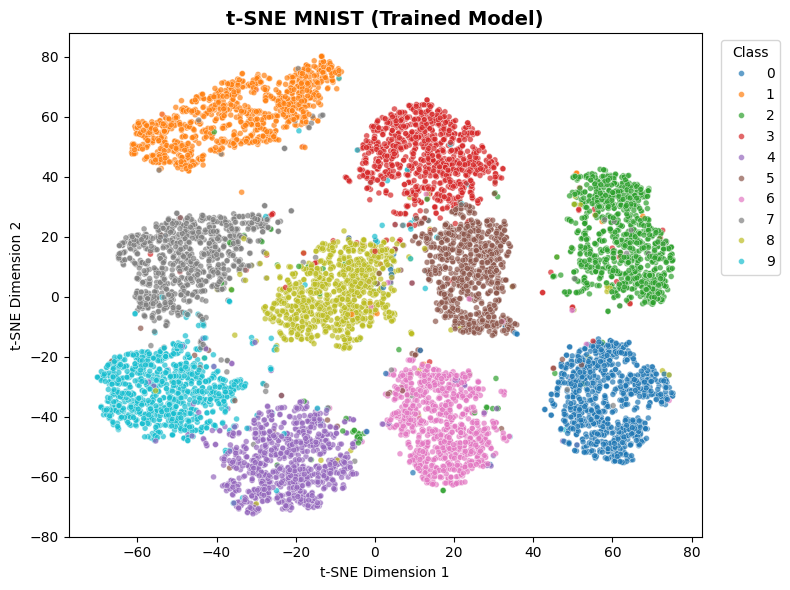

In [26]:
# ---------- TRAINED MODEL ----------
trained_feats, trained_lbls = extract_features(model, FullDtestDL, device, layer_no)
plot_tsne(trained_feats, trained_lbls, "t-SNE MNIST (Trained Model)")

###  t-SNE - FashionMNIST (Trained on MNIST)

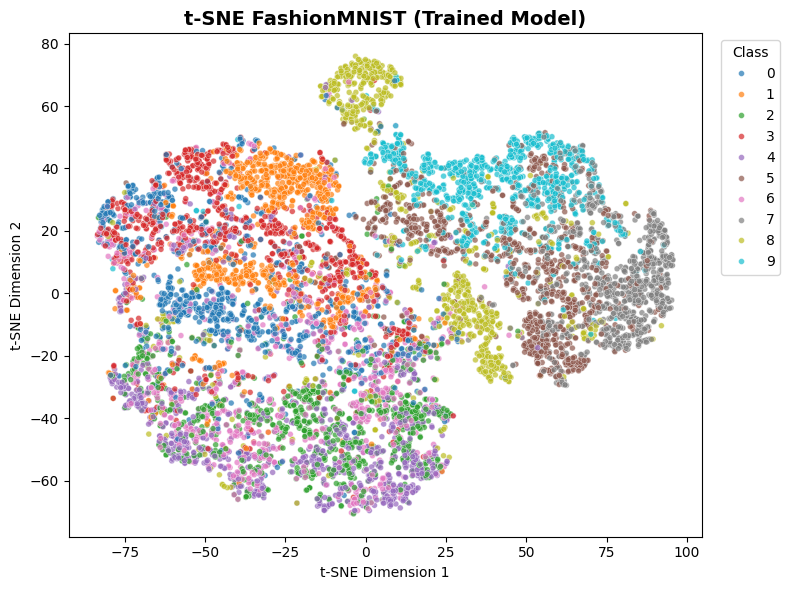

In [27]:
# ---------- TRAINED MODEL ----------
trained_feats, trained_lbls = extract_features(model, FullFtestDL, device, layer_no)
plot_tsne(trained_feats, trained_lbls, "t-SNE FashionMNIST (Trained Model)")

### t-SNE - MNIST Untrained

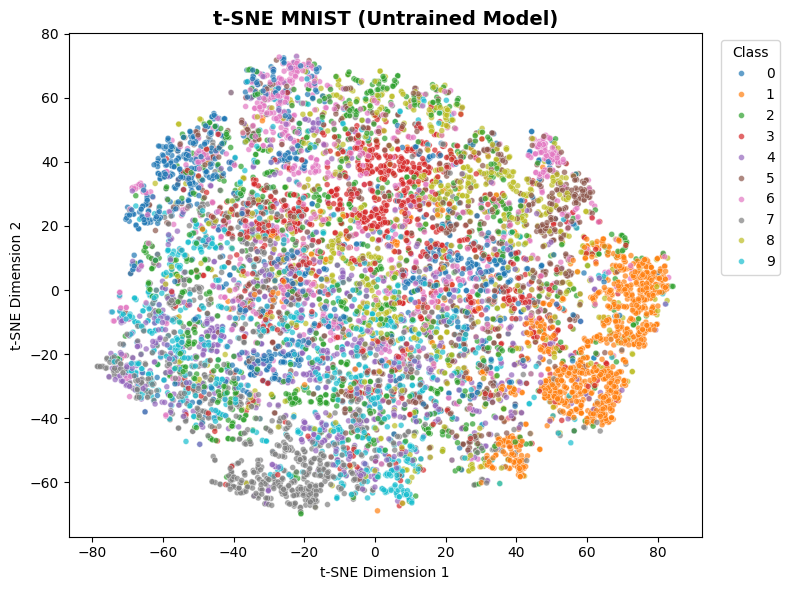

In [28]:
# ---------- UNTRAINED MODEL ----------
untrained_model = FM_ANN_Dynamic(
    lin=(400, 20, "res"), initSize=784, nClasses=10, activ="ReLU", bn=False
).to(device)

untrained_feats, untrained_lbls = extract_features(untrained_model, testDL, device, layer_no)
plot_tsne(untrained_feats, untrained_lbls, "t-SNE MNIST (Untrained Model)")


# CNN

In [29]:
CNNmodel = DR_CNN_Dynamic (convConfig=(1,32), bnAt = (1,), mpAt = (1,), 
                        convKSP = ((3,3),1,0), poolMSP = ((2,2),2,0), 
                        lin = (128,"res"), showDim = True)

print("\n", "-"*50, sep="")
print(CNNmodel)

Init : (28, 1)
Cv 0 : (26, 32)
BN 0 : (26, 32)
MP 0 : (13, 32)
Fltn : 5408
FCNW : 128
FCNW : 10
Result Size: 10

--------------------------------------------------
DR_CNN_Dynamic(
  (layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=5408, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
  (mp): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
)


In [30]:
CNNmodel=CNNmodel.to(device)
loss_fn=nn.CrossEntropyLoss()
lr=0.001
# optimizer=torch.optim.SGD(params=CNNmodel.parameters(), lr=lr)
optimizer=torch.optim.Adam(params=CNNmodel.parameters(), lr=lr)
n_epochs=50

print(CNNmodel)

for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=epochTrainer(trainDL,CNNmodel,loss_fn,optimizer, ver=False)
    print("Training  :", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    val_epoch_loss, val_epoch_acc=epochValidate(testDL,CNNmodel,loss_fn, ver = False)
    print("Test      :", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc*100)
    print("--------------------------------------------------")

DR_CNN_Dynamic(
  (layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=5408, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
  (mp): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
)
Epoch No: 1
Training  : Epoch Loss: 0.1588 Epoch Accuracy: 96.195
Test      : Epoch Loss: 0.0613 Epoch Accuracy: 98.13
--------------------------------------------------
Epoch No: 2
Training  : Epoch Loss: 0.0492 Epoch Accuracy: 98.4767
Test      : Epoch Loss: 0.0452 Epoch Accuracy: 98.45
-----------------------------------

Test      :
Precision     : 99.04%
Recall        : 99.04%
F1-Score      : 99.04%


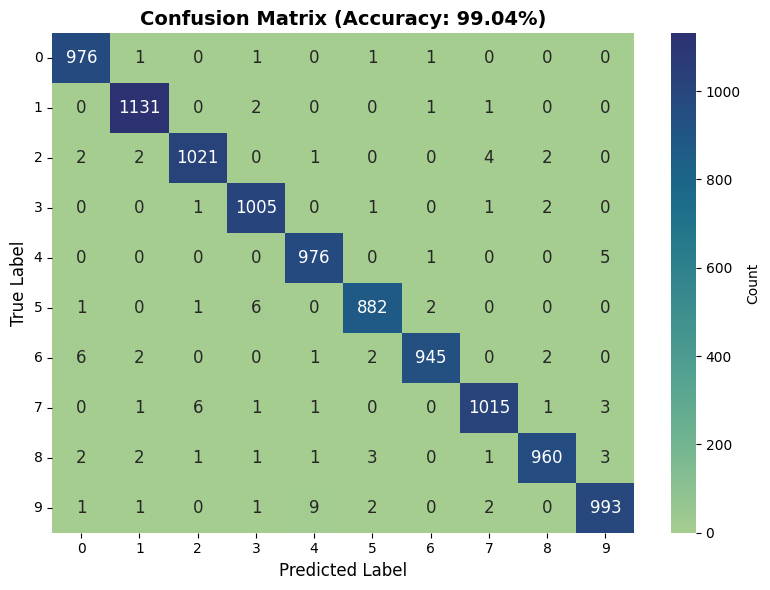

In [31]:
_ = epochValidate(FullDtestDL,CNNmodel,loss_fn, ver = False, metric = True)

In [32]:
def countParams(model, detailed=True):

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    print("="*60)
    print(f"Model Summary: {model.__class__.__name__}")
    print(f"Total Parameters:       {total_params:,}")
    print(f"Trainable Parameters:   {trainable_params:,}")
    print(f"Non-trainable Params:   {non_trainable_params:,}")
    print("="*60)
    
    if detailed:
        print(f"{'Layer':40} | {'Parameters':>12} | {'Trainable':>10}")
        print("-"*70)
        for name, param in model.named_parameters():
            print(f"{name:40} | {param.numel():12,} | {str(param.requires_grad):>10}")
        print("="*60)

    return {
        "total": total_params,
        "trainable": trainable_params,
        "non_trainable": non_trainable_params
    }


In [33]:
_ = countParams(CNNmodel)

Model Summary: DR_CNN_Dynamic
Total Parameters:       694,282
Trainable Parameters:   694,282
Non-trainable Params:   0
Layer                                    |   Parameters |  Trainable
----------------------------------------------------------------------
layers.0.weight                          |          288 |       True
layers.0.bias                            |           32 |       True
layers.1.weight                          |           32 |       True
layers.1.bias                            |           32 |       True
layers.5.weight                          |      692,224 |       True
layers.5.bias                            |          128 |       True
layers.6.weight                          |          128 |       True
layers.6.bias                            |          128 |       True
layers.8.weight                          |        1,280 |       True
layers.8.bias                            |           10 |       True


## Pretrained - ResNet18

In [34]:
Res18model = models.resnet18(pretrained=True)
for param in Res18model.parameters():
    param.requires_grad = False

Res18model.fc = nn.Linear(Res18model.fc.in_features, 10)
FCParams = Res18model.fc.parameters()

Res18model = Res18model.to(device)
lr=0.001
optimizer = torch.optim.Adam(FCParams, lr=lr)

loss_fn = nn.CrossEntropyLoss()
n_epochs=50

Res18transform = transforms.Compose([
    transforms.Resize((56, 56)),  # ResNet expects 224×224
    transforms.Grayscale(num_output_channels=3),  # replicate channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                         std=[0.229, 0.224, 0.225]),
])
batch_size = 64

Res18testDS = datasets.MNIST(root='./data', train=False, transform=Res18transform, download=True)
Res18trainDS = datasets.MNIST(root='./data', train=True, transform=Res18transform, download=True)
Res18testDL = DataLoader(Res18testDS, batch_size=batch_size, shuffle=False,
    num_workers=16,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True)
Res18trainDL = DataLoader(Res18trainDS, batch_size=batch_size, shuffle=True,
    num_workers=16,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True)
Res18FulltestDL = DataLoader(Res18testDS, batch_size=len(Res18testDS), shuffle=False,
    num_workers=16,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True)
Res18FulltrainDL = DataLoader(Res18trainDS, batch_size=len(Res18testDS), shuffle=False,
    num_workers=16,          # use half your CPU cores
    pin_memory=True,
    persistent_workers=True)

Res18model.eval()

print(Res18model)
_ = countParams(Res18model)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
print(torch.cuda.memory_allocated()/1e6, "MB allocated")
print(torch.cuda.memory_reserved()/1e6, "MB reserved")


68.946432 MB allocated
1870.659584 MB reserved


In [36]:
torch.cuda.empty_cache()

Test      :
Precision     : 12.05%
Recall        : 10.33%
F1-Score      : 3.0%


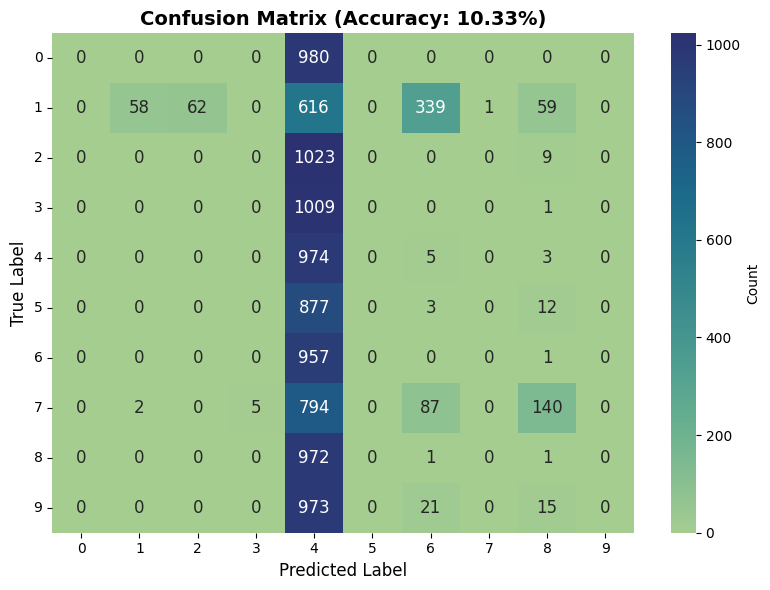

In [37]:
_ = epochValidate(Res18FulltestDL,Res18model,loss_fn, ver = False, metric = True)

In [38]:
torch.cuda.empty_cache()

In [39]:
pin_memory=True

In [40]:
print(Res18trainDS)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=(56, 56), interpolation=bilinear, max_size=None, antialias=True)
               Grayscale(num_output_channels=3)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [41]:
print(Res18testDS)

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               Resize(size=(56, 56), interpolation=bilinear, max_size=None, antialias=True)
               Grayscale(num_output_channels=3)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [42]:
for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=epochTrainer(Res18trainDL,Res18model,loss_fn,optimizer, ver=False, PT=True)
    print("Training  :", "Epoch Loss:", train_epoch_loss)
    val_epoch_loss, val_epoch_acc=epochValidate(Res18testDL,Res18model,loss_fn, ver = False)
    print("Test      :", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc*100)
    print("--------------------------------------------------")

Epoch No: 1
Training  : Epoch Loss: 0.4009
Test      : Epoch Loss: 0.209 Epoch Accuracy: 94.21000000000001
--------------------------------------------------
Epoch No: 2
Training  : Epoch Loss: 0.1911
Test      : Epoch Loss: 0.1657 Epoch Accuracy: 94.97
--------------------------------------------------
Epoch No: 3
Training  : Epoch Loss: 0.156
Test      : Epoch Loss: 0.1488 Epoch Accuracy: 95.44
--------------------------------------------------
Epoch No: 4
Training  : Epoch Loss: 0.1364
Test      : Epoch Loss: 0.1273 Epoch Accuracy: 96.21
--------------------------------------------------
Epoch No: 5
Training  : Epoch Loss: 0.1243
Test      : Epoch Loss: 0.1253 Epoch Accuracy: 96.08
--------------------------------------------------
Epoch No: 6
Training  : Epoch Loss: 0.1164
Test      : Epoch Loss: 0.1213 Epoch Accuracy: 96.11
--------------------------------------------------
Epoch No: 7
Training  : Epoch Loss: 0.1097
Test      : Epoch Loss: 0.1212 Epoch Accuracy: 96.1
-------------

### On Test Data

Test      :
Precision     : 96.94%
Recall        : 96.92%
F1-Score      : 96.92%


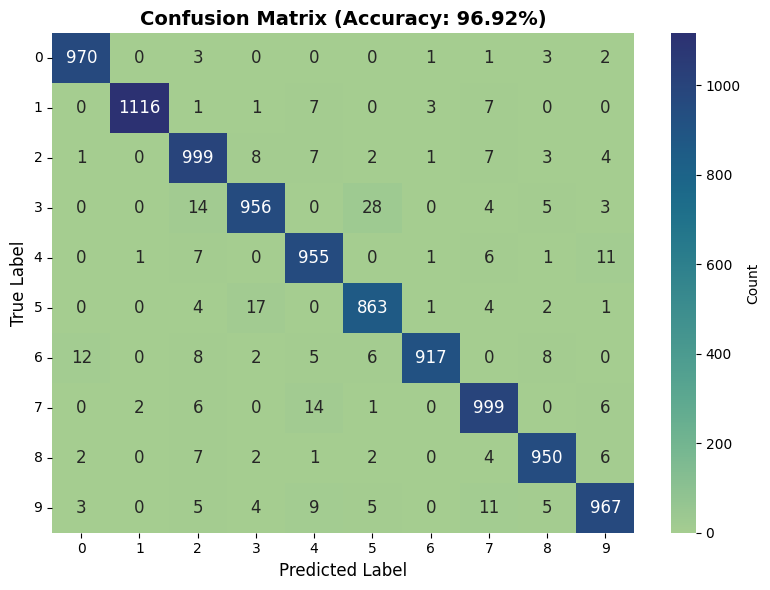

In [43]:
_ = epochValidate(Res18FulltestDL,Res18model,loss_fn, ver = False, metric = True)

### On Train Data

Test      :
Precision     : 98.52%
Recall        : 98.51%
F1-Score      : 98.51%


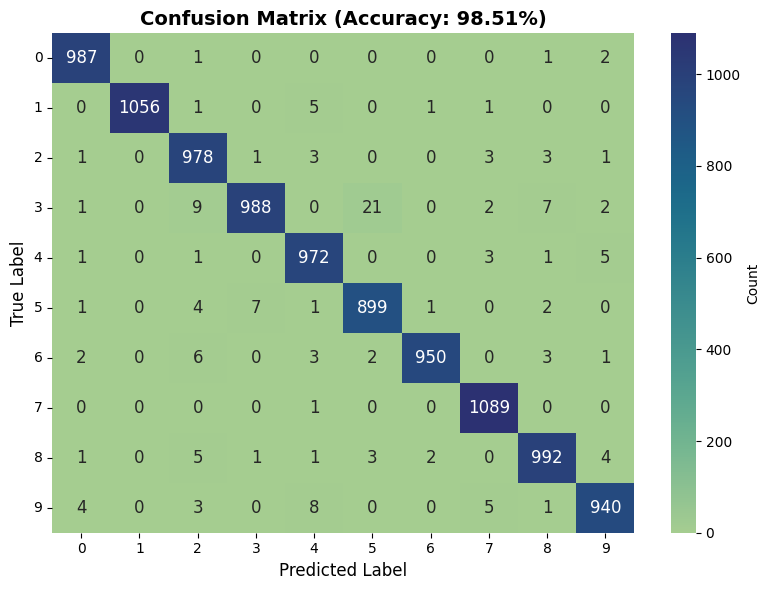

In [44]:
_ = epochValidate(Res18FulltrainDL,Res18model,loss_fn, ver = False, metric = True)

## Pre-Trained - MobileNet

In [45]:
# def reset_gpu():
#     import os
#     import gc
#     os.environ["CUDA_VISIBLE_DEVICES"] = ""
#     torch.cuda.empty_cache()
#     gc.collect()
#     torch.cuda.empty_cache()

In [46]:
torch.cuda.empty_cache()

In [47]:
mobilenet = models.mobilenet_v2(pretrained=True)

for param in mobilenet.features.parameters():
    param.requires_grad = False

mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 10)

mobilenet = mobilenet.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mobilenet.classifier.parameters(), lr=0.001)


# MNetTransform = transforms.Compose([
#     transforms.Resize((96, 96)),                 # smaller than 224 to save VRAM
#     transforms.Grayscale(num_output_channels=3), # replicate channels
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# batch_size = 32
# MNettrainDS = datasets.MNIST(root='./data', train=True, transform=MNetTransform, download=True)
# MNettestDS  = datasets.MNIST(root='./data', train=False, transform=MNetTransform, download=True)

# MNettestDL = DataLoader(MNettestDS, batch_size=batch_size, shuffle=False)
# MNettrainDL = DataLoader(MNettrainDS, batch_size=batch_size, shuffle=True)
# MNetFulltestDL = DataLoader(MNettestDS, batch_size=len(Res18testDS), shuffle=False)
# MNetFulltrainDL = DataLoader(MNettrainDS, batch_size=len(Res18testDS), shuffle=False)

mobilenet.eval()

print(mobilenet)
_ = countParams(mobilenet)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [48]:
torch.cuda.empty_cache()

Test      :
Precision     : 7.46%
Recall        : 9.37%
F1-Score      : 3.38%


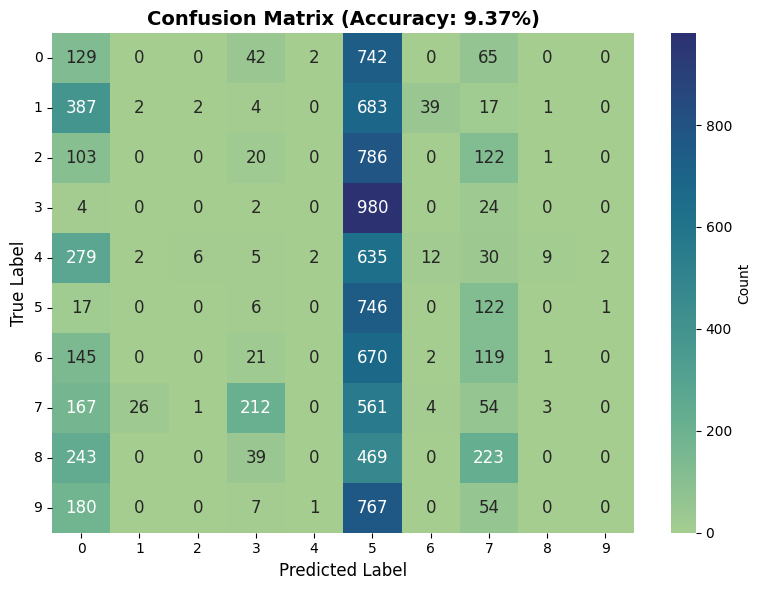

In [49]:
_ = epochValidate(Res18FulltestDL,mobilenet,loss_fn, ver = False, metric = True)

In [50]:
torch.cuda.empty_cache()

In [51]:
for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=epochTrainer(Res18trainDL,mobilenet,loss_fn,optimizer, ver=False, PT=True)
    print("Training  :", "Epoch Loss:", train_epoch_loss)
    val_epoch_loss, val_epoch_acc=epochValidate(Res18testDL,mobilenet,loss_fn, ver = False)
    print("Test      :", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc*100)
    print("--------------------------------------------------")

Epoch No: 1
Training  : Epoch Loss: 0.4695
Test      : Epoch Loss: 0.2729 Epoch Accuracy: 92.13
--------------------------------------------------
Epoch No: 2
Training  : Epoch Loss: 0.2374
Test      : Epoch Loss: 0.2101 Epoch Accuracy: 93.97
--------------------------------------------------
Epoch No: 3
Training  : Epoch Loss: 0.1921
Test      : Epoch Loss: 0.1834 Epoch Accuracy: 94.77
--------------------------------------------------
Epoch No: 4
Training  : Epoch Loss: 0.1684
Test      : Epoch Loss: 0.1681 Epoch Accuracy: 95.00999999999999
--------------------------------------------------
Epoch No: 5
Training  : Epoch Loss: 0.1522
Test      : Epoch Loss: 0.1531 Epoch Accuracy: 95.48
--------------------------------------------------
Epoch No: 6
Training  : Epoch Loss: 0.1411
Test      : Epoch Loss: 0.1444 Epoch Accuracy: 95.62
--------------------------------------------------
Epoch No: 7
Training  : Epoch Loss: 0.1311
Test      : Epoch Loss: 0.1455 Epoch Accuracy: 95.71
----------

Test      :
Precision     : 96.16%
Recall        : 96.13%
F1-Score      : 96.13%


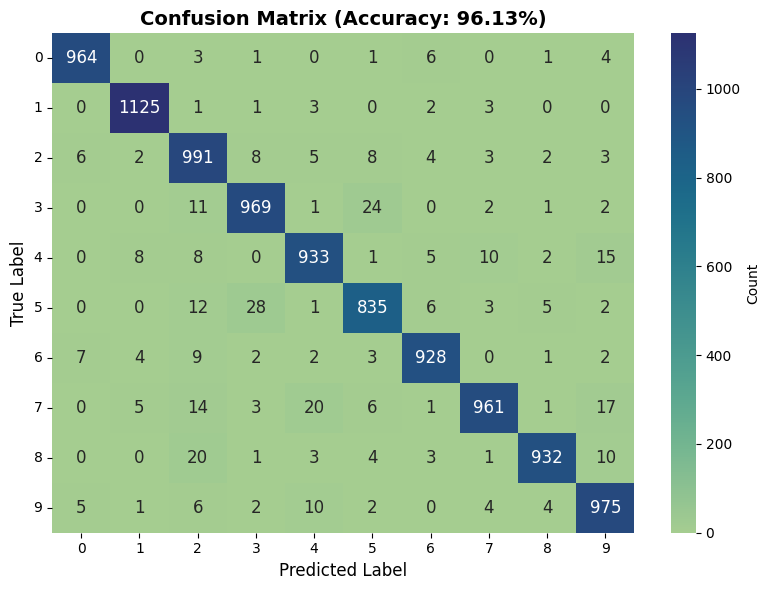

In [52]:
_ = epochValidate(Res18FulltestDL,mobilenet,loss_fn, ver = False, metric = True)

# ANN - Comparisions

## 1. ANN vs. Randon Forest and Logistic Regression

ANN
Test      :
Precision     : 96.53%
Recall        : 96.52%
F1-Score      : 96.52%


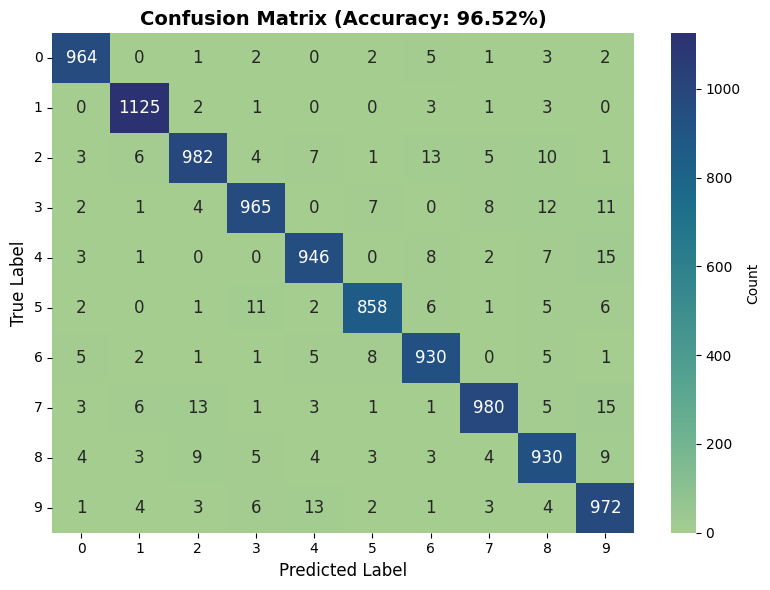

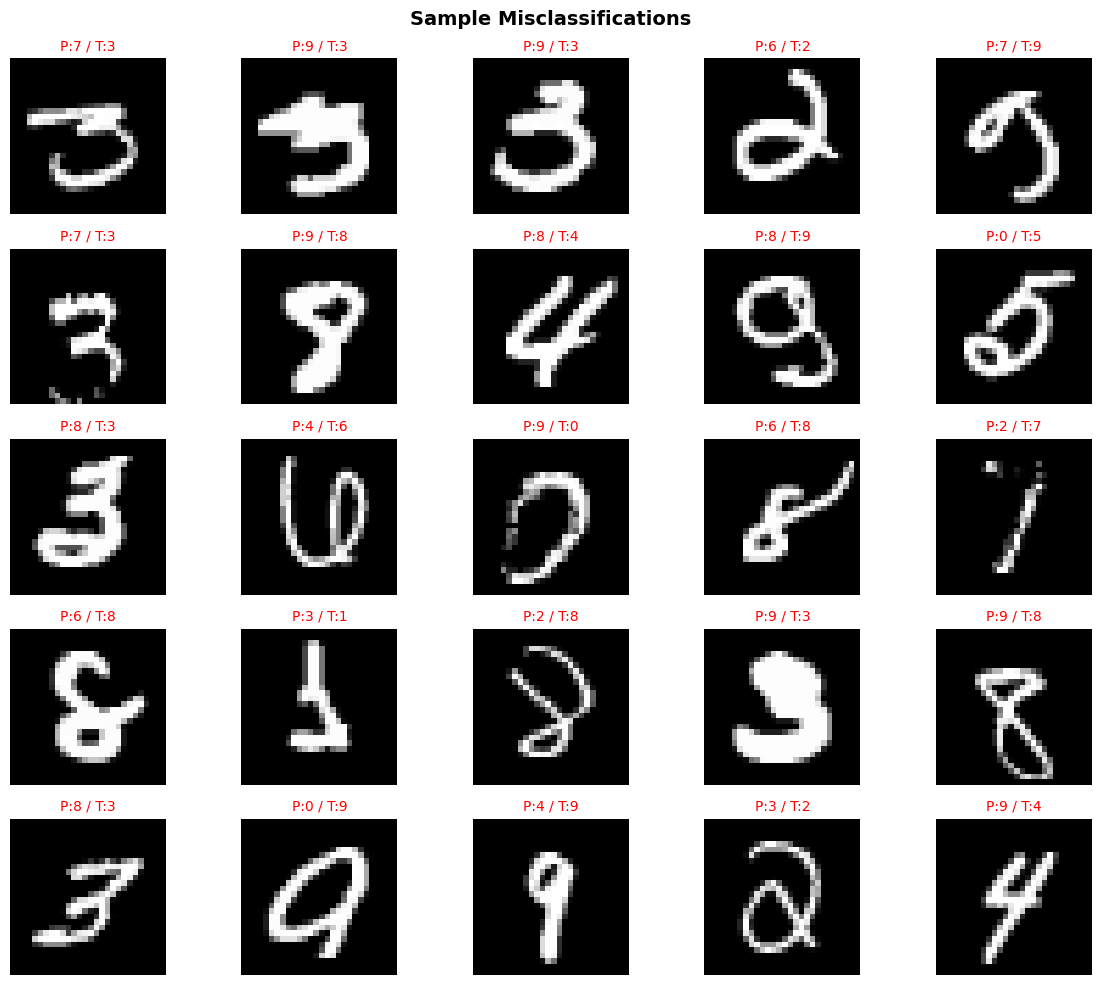

LR
Test      :
Precision     : 92.62%
Recall        : 92.59%
F1-Score      : 92.58%


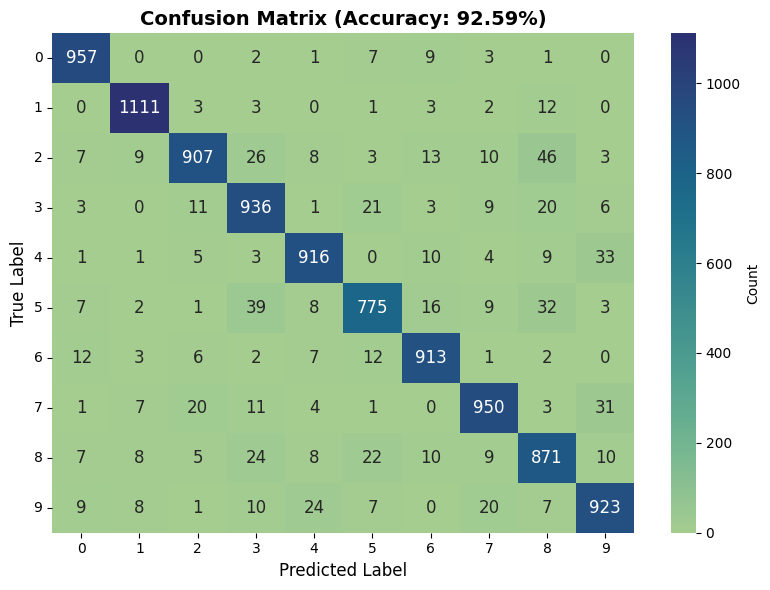

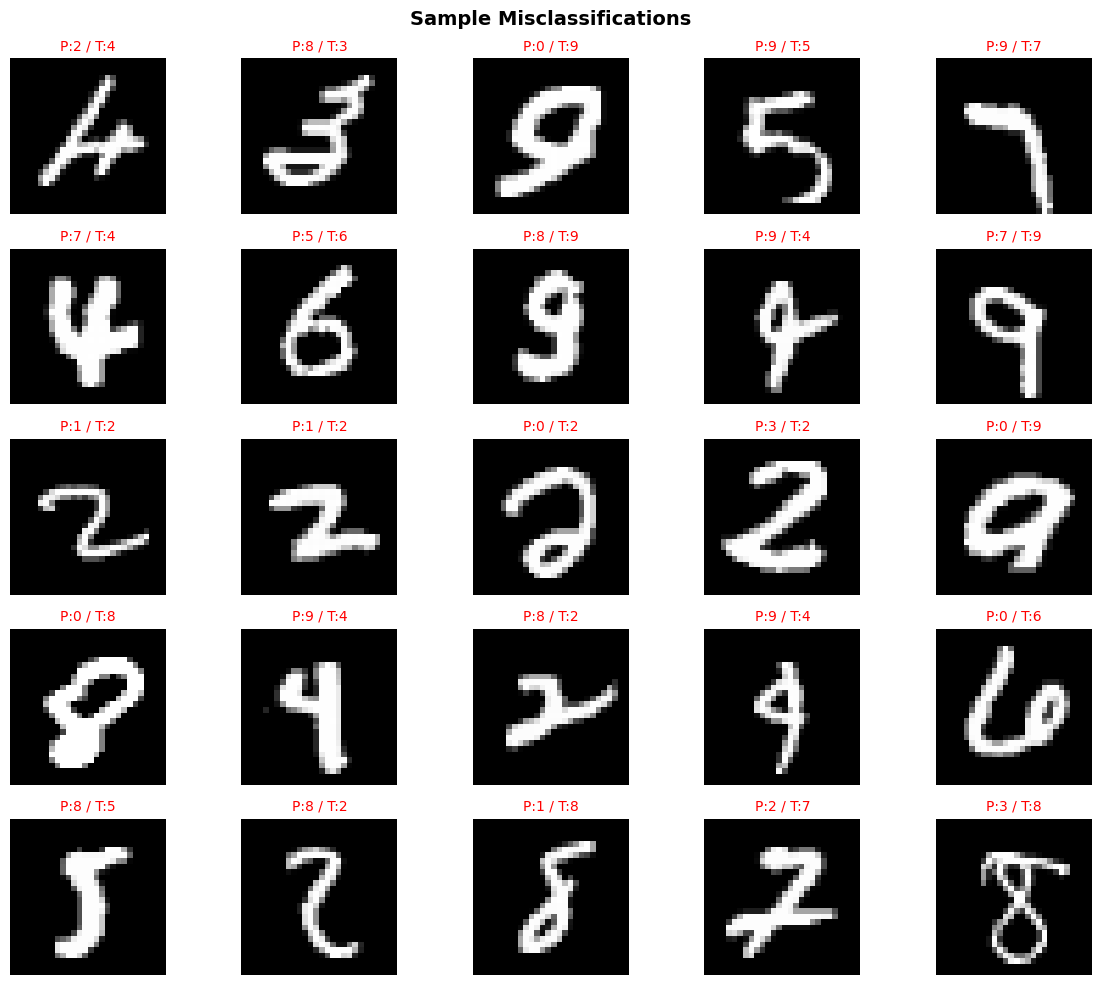

RF

Random Forest:
Accuracy : 96.8%
Precision: 96.8%
Recall   : 96.8%
F1-score : 96.8%


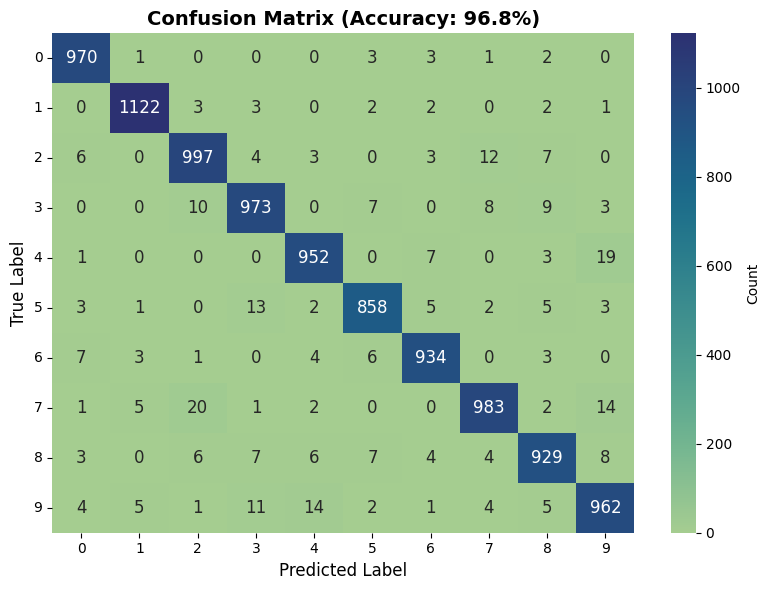


Total misclassifications: 320 / 10000


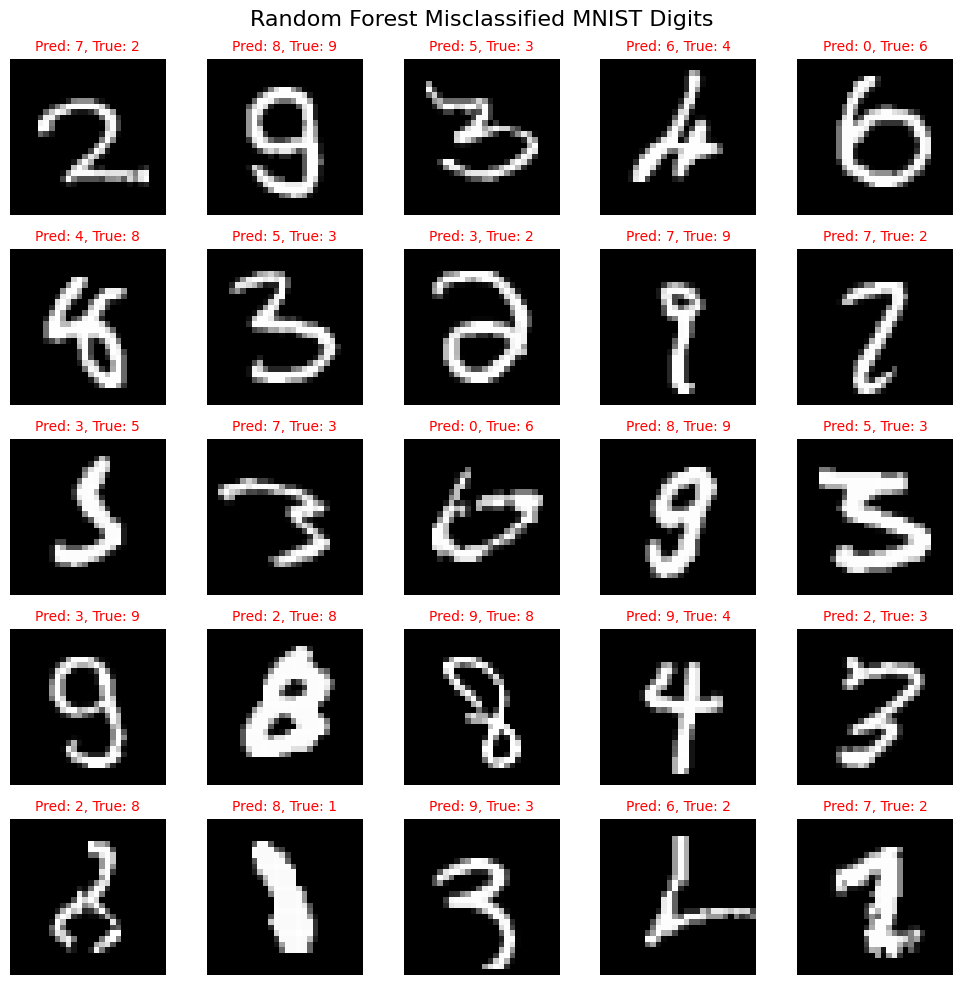

In [75]:
print("ANN")
_ = epochValidate(FullDtestDL,model,loss_fn, ver = False, metric = True, show_mis = True)

print("LR")
_ = epochValidate(FullDtestDL,lrmodel,loss_fn, ver = False, metric = True, show_mis = True)

print("RF")
testRF(y_test,y_pred)

Observations: 

* All models performs similarly, with LR performing slightly worse.
* Most of the misclasssifications, especially in ANN models seems understandable. such as 2 miscalssified as 7, as it loooks like 7 with aline at bottom


## 2. SNE

t-SNE - MNIST Trained


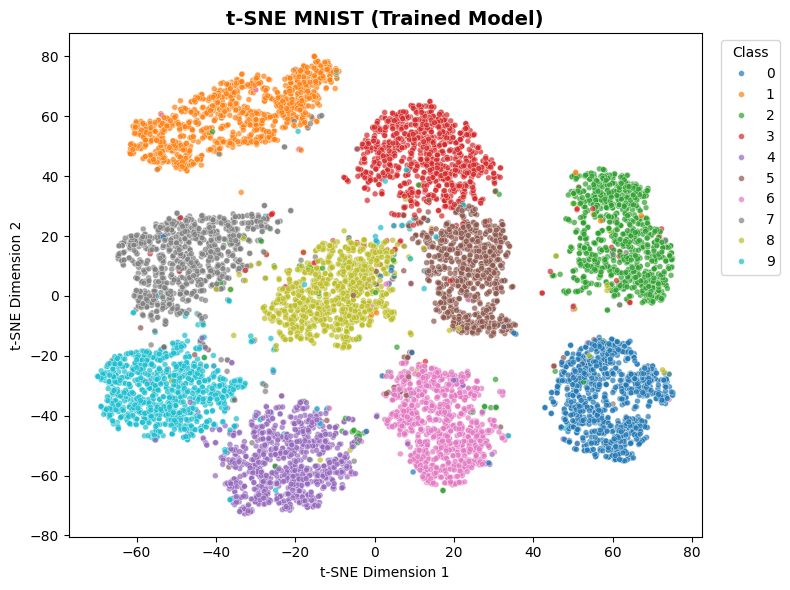

t-SNE - FashionMNIST (Trained on MNIST)


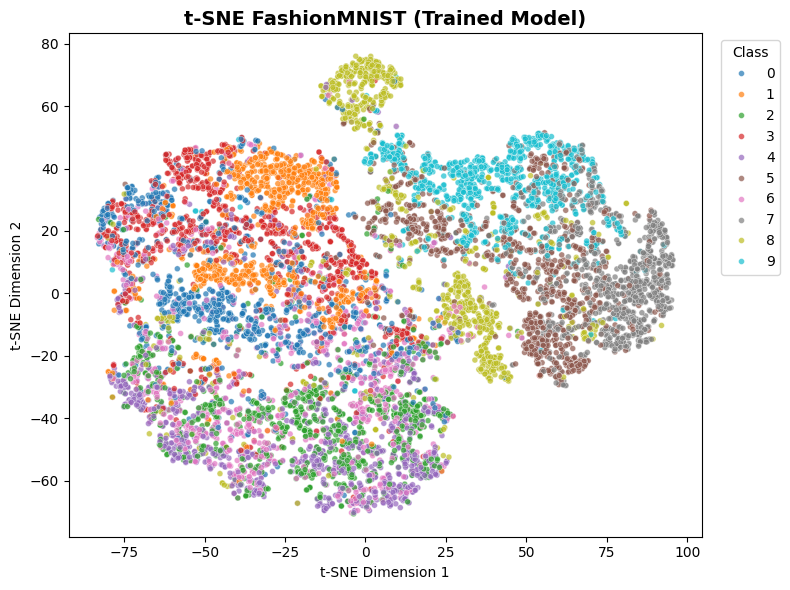

t-SNE - MNIST Untrained


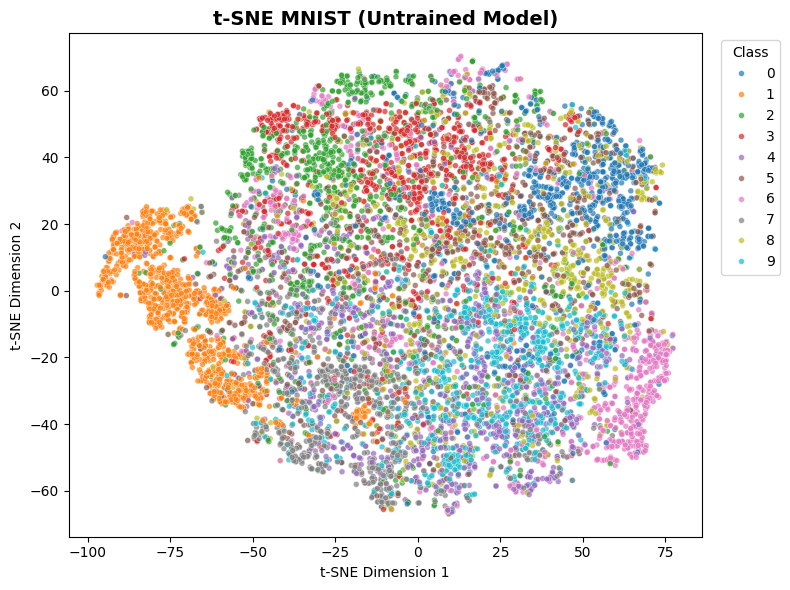

In [77]:
print ("t-SNE - MNIST Trained")
trained_feats, trained_lbls = extract_features(model, FullDtestDL, device, layer_no)
plot_tsne(trained_feats, trained_lbls, "t-SNE MNIST (Trained Model)")


print("t-SNE - FashionMNIST (Trained on MNIST)")
trained_feats, trained_lbls = extract_features(model, FullFtestDL, device, layer_no)
plot_tsne(trained_feats, trained_lbls, "t-SNE FashionMNIST (Trained Model)")



print("t-SNE - MNIST Untrained")
untrained_model = FM_ANN_Dynamic(
    lin=(400, 20, "res"), initSize=784, nClasses=10, activ="ReLU", bn=False
).to(device)

untrained_feats, untrained_lbls = extract_features(untrained_model, testDL, device, layer_no)
plot_tsne(untrained_feats, untrained_lbls, "t-SNE MNIST (Untrained Model)")


Observation: It is clear by t-SNe plots that the trained model is well seggregated, whereas other models are mixed up and random guessing

## 3. FashionMNIST

Test      :
Precision     : 8.77%
Recall        : 3.94%
F1-Score      : 3.22%


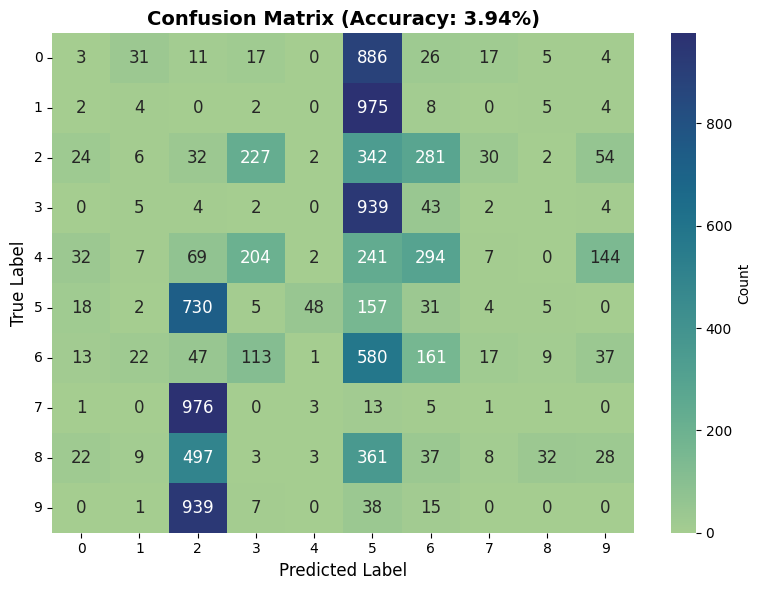

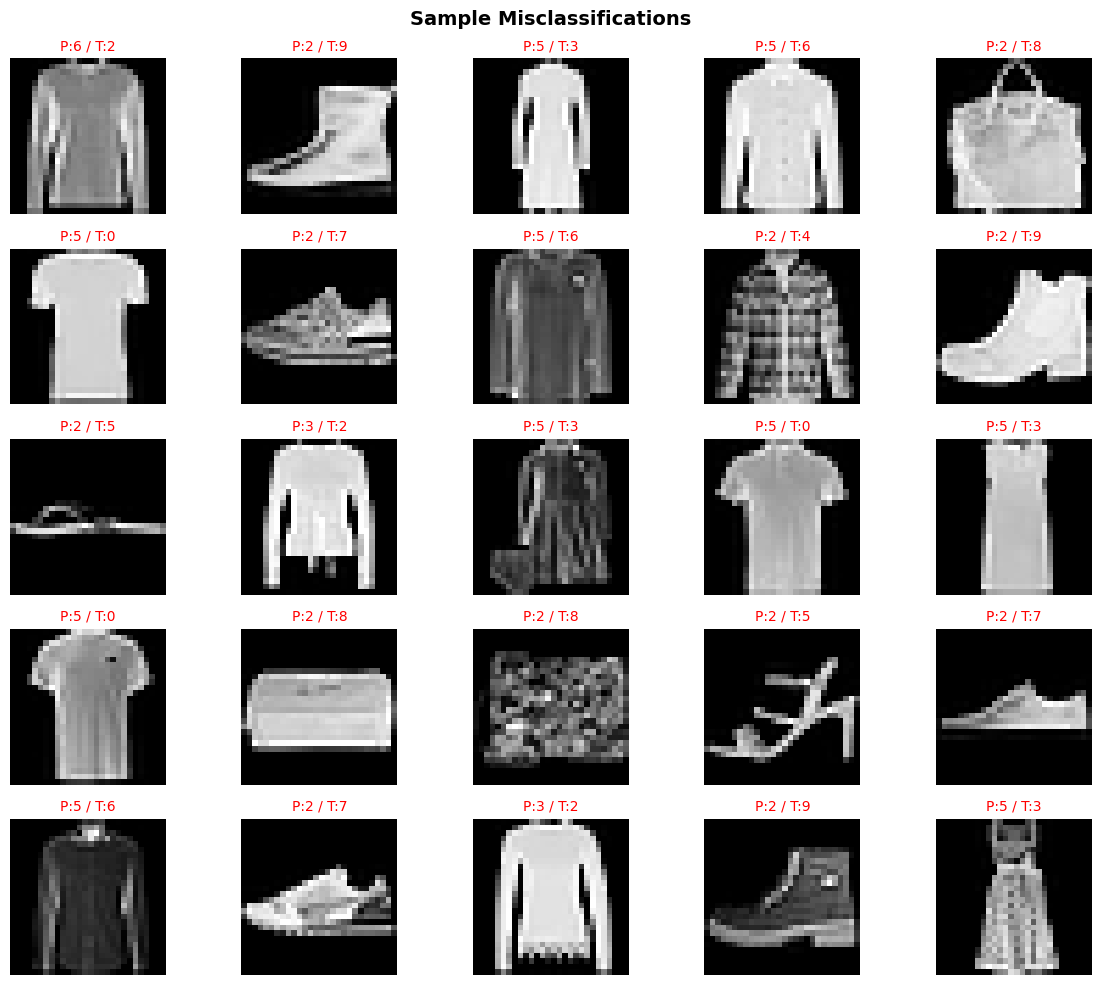

In [78]:
_ = epochValidate(FullFtestDL,model,loss_fn, ver = False, metric = True, show_mis = True)

Observation: Model performs as well or worse than random chance, depending on how whe weights got initialized.

t-SNE - MNIST Trained


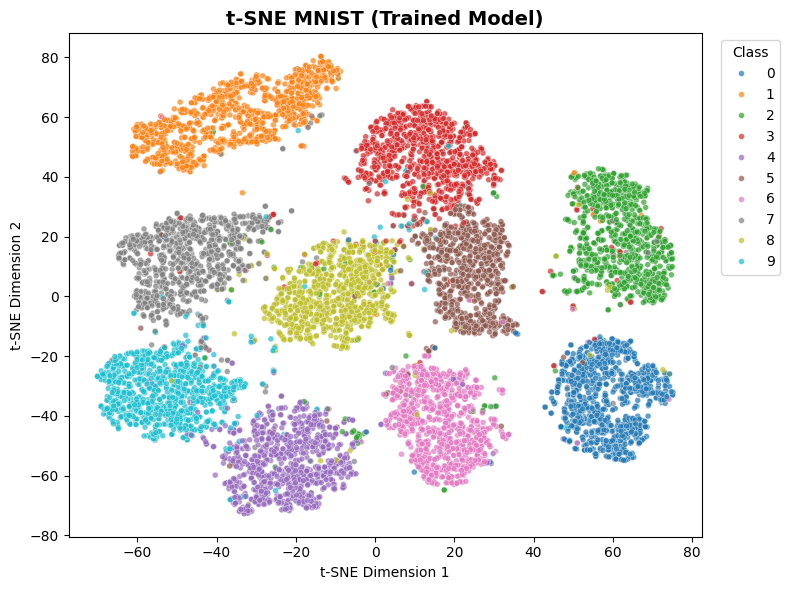

t-SNE - FashionMNIST (Trained on MNIST)


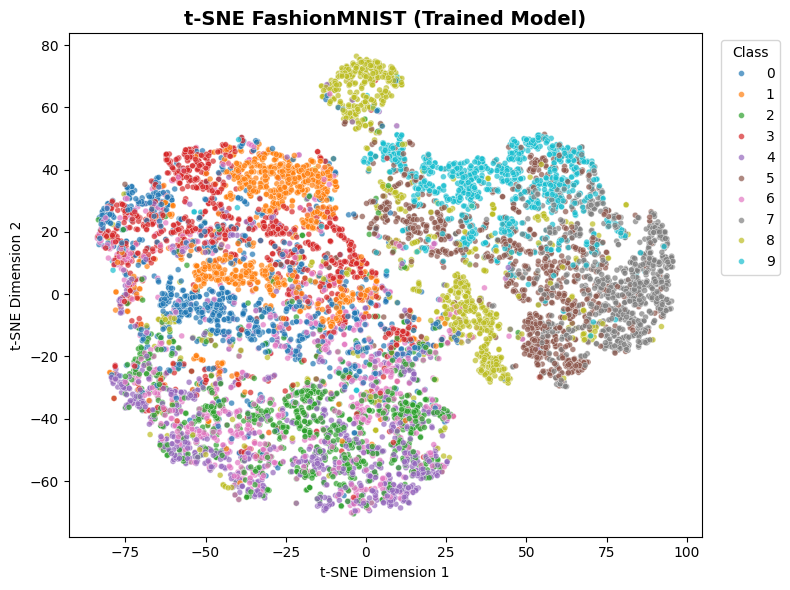

In [79]:
print ("t-SNE - MNIST Trained")
trained_feats, trained_lbls = extract_features(model, FullDtestDL, device, layer_no)
plot_tsne(trained_feats, trained_lbls, "t-SNE MNIST (Trained Model)")


print("t-SNE - FashionMNIST (Trained on MNIST)")
trained_feats, trained_lbls = extract_features(model, FullFtestDL, device, layer_no)
plot_tsne(trained_feats, trained_lbls, "t-SNE FashionMNIST (Trained Model)")



Observation: It is clear by t-SNe plots that the MIST trained model on MNIST is well seggregated, whereas when passed with FasionMNIST, is mixed up and random guessing

# CNN - Comparisions

In [53]:
import time
def inferTime(data,model,loss_fn):
    start_time = time.time()

    _ = epochValidate(data,model,loss_fn, ver = False, metric = False)

    end_time = time.time()

    total_time = end_time - start_time
    num_images = len(data.dataset)
    avg_time_per_image = total_time / num_images

    print(f"Total inference time on test set: {total_time:.4f} seconds")
    print(f"Average time per image: {avg_time_per_image*1000:.4f} ms")


### 1. Accuracy, F1 Score, Confusion Matrix

CNN
Test      :
Precision     : 99.04%
Recall        : 99.04%
F1-Score      : 99.04%


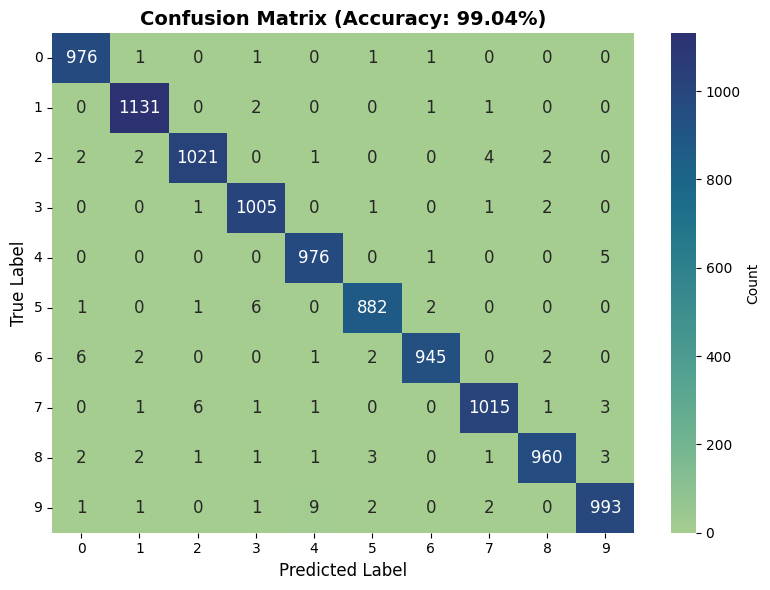

ResNet18
Test      :
Precision     : 96.94%
Recall        : 96.92%
F1-Score      : 96.92%


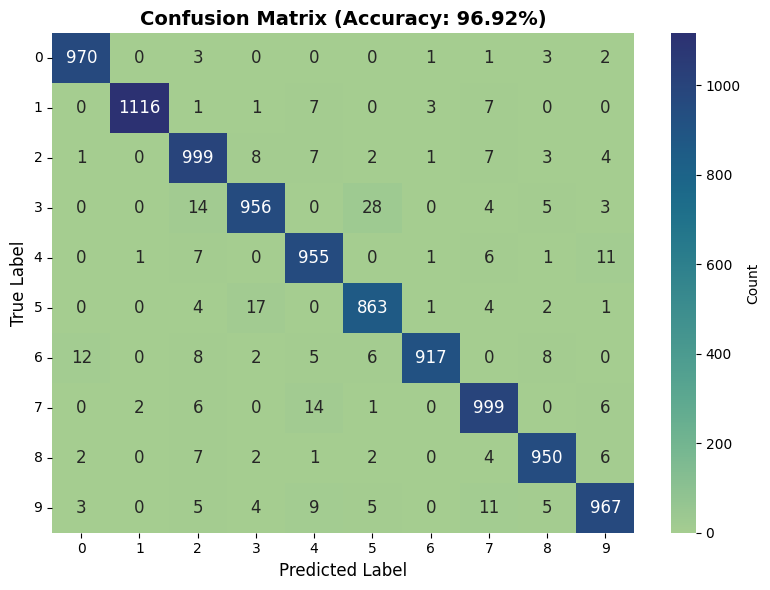

MobileNet
Test      :
Precision     : 96.16%
Recall        : 96.13%
F1-Score      : 96.13%


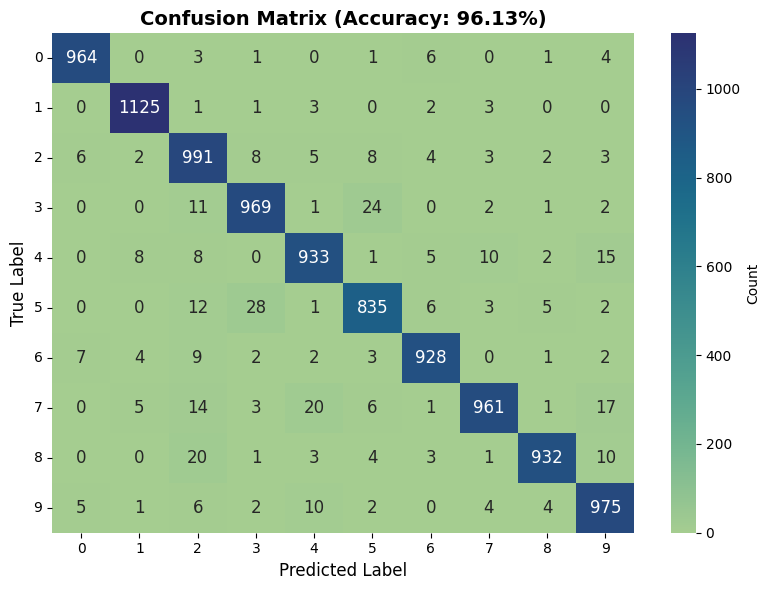

In [66]:
print("CNN")
_ = epochValidate(FullDtestDL,CNNmodel,loss_fn, ver = False, metric = True)
print("ResNet18")
_ = epochValidate(Res18FulltestDL,Res18model,loss_fn, ver = False, metric = True)
print("MobileNet")
_ = epochValidate(Res18FulltestDL,mobilenet,loss_fn, ver = False, metric = True)

### 2. Model Size

In [71]:
print("CNN")
_ = countParams(CNNmodel, detailed = False)
print("ResNet18")
_ = countParams(Res18model, detailed = False)
print("MobileNet")
_ = countParams(mobilenet, detailed = False)

CNN
Model Summary: DR_CNN_Dynamic
Total Parameters:       694,282
Trainable Parameters:   694,282
Non-trainable Params:   0
ResNet18
Model Summary: ResNet
Total Parameters:       11,181,642
Trainable Parameters:   5,130
Non-trainable Params:   11,176,512
MobileNet
Model Summary: MobileNetV2
Total Parameters:       2,236,682
Trainable Parameters:   12,810
Non-trainable Params:   2,223,872


### 3. Infer Time Comparision

In [73]:
print("CNN")
inferTime(Res18FulltestDL,mobilenet,loss_fn)
print("\nResNet18")
inferTime(Res18FulltestDL,mobilenet,loss_fn)
print("\nMobileNet")
inferTime(Res18FulltestDL,mobilenet,loss_fn)

CNN


Total inference time on test set: 4.2640 seconds
Average time per image: 0.4264 ms

ResNet18
Total inference time on test set: 4.2509 seconds
Average time per image: 0.4251 ms

MobileNet
Total inference time on test set: 4.2509 seconds
Average time per image: 0.4251 ms
